Put logo

## Curve Bootstrapping

In [1]:
%load_ext autoreload
%autoreload 2

#imports
import datetime as dt
from dateutil.relativedelta import relativedelta
import pandas as pd
import matplotlib.pyplot as plt
from rivapy.marketdata.bootstrapping_2025 import bootstrap_curve, get_quote
from rivapy.instruments.deposit_specifications import DepositSpecification
from rivapy.instruments.fra_specifications import ForwardRateAgreementSpecification
from rivapy.instruments.ir_swap_specification import InterestRateSwapSpecification, IrFixedLegSpecification, IrFloatLegSpecification, IrOISLegSpecification
from rivapy.instruments.notional_structure import ConstNotionalStructure
from rivapy.tools.enums import DayCounterType, InterpolationType, ExtrapolationType

import matplotlib.pyplot as plt
import math
from rivapy.tools.datetools import DayCounter
from rivapy.tools._validators import print_member_values
from rivapy.pricing.deposit_pricing import DepositPricer
from rivapy.pricing.interest_rate_swap_pricing import InterestRateSwapPricer
from rivapy.marketdata.curves import DiscountCurve

c:\Users\DrHansNguyen\anaconda3\envs\rivapy3.11\Lib\site-packages\pyvacon\__init__.py:12: UserWarning: Imported pyvacon is just beta version.
  _warnings.warn('Imported pyvacon is just beta version.')
c:\Users\DrHansNguyen\Documents\MyRivacon\RiVaPy\rivapy\__init__.py:9: UserWarning: Imported pyvacon is just beta version.
  warnings.warn('Imported pyvacon is just beta version.')


In [2]:
#set up instruments
#set up deposit
#set up ir_swap



### Setting up deposits / fixings

The fixing of the underlying reference rate is published daily and represents a certain average rate earned over a period corresponding to the tenor. The rate is calculated from quotes obtained from a panel of selected banks. The start date (spot date) of the period can deviate from the fixing date. This difference is referred to as the spot lag. 

The fixing is usually used as the starting point for the bootstrapping of forward curves. It can be specified as a deposit in pyvacon.

In [3]:
##########################################
# setting up depoist
# calculation date
ref_date = dt.datetime(2019, 8, 31) # refdate = dt.datetime(2017, 8, 31)

# start date of the accrual period with spot lag equal to 2 days
start_date = ref_date + dt.timedelta(days=2)

# end date of the accrual period is 1 day after startdate
end_date = start_date + dt.timedelta(days=1)

# specification of the deposit
ccy = "EUR"
dcc = "Act365Fixed"#"Act360"normally a bond is ACT360, we keep consistency with the swaps
rate = 0.01
notional = 100.0
deposit = DepositSpecification(
    obj_id="OVERNIGHT_DEPOSIT",
    issuer="dummy_issuer",
    currency=ccy,
    fixing_date=ref_date,
    start_date=start_date,
    maturity_date=end_date,
    notional=notional,
    rate=rate,
    day_count_convention=dcc,
)

# check dates, deposit start date cannot be the same as  maturity date
print(f"ref date: {ref_date}")
print(f"start date: {start_date} with spot lag 2 days")
print(f"end date: {end_date}")
print(f"adjusted start date: {deposit.start_date}")
print(f"adjusted end date: {deposit.maturity_date}")

print_member_values(deposit)

#Note that a fixed rate is given for the specification as it is required. However, for the creation of the bootrstrapped curve, the market quotes are used



Set fixing_date, 2019-08-31 00:00:00, to next business day acc. to business_day_convention:2019-08-30 00:00:00
Set term to the difference between end_date and start_date in days.
ref date: 2019-08-31 00:00:00
start date: 2019-09-02 00:00:00 with spot lag 2 days
end date: 2019-09-03 00:00:00
adjusted start date: 2019-09-02 00:00:00
adjusted end date: 2019-09-03 00:00:00
Inspecting instance of DepositSpecification:

backwards: True
business_day_convention: RollConvention.MODIFIED_FOLLOWING
calendar: {datetime.date(2019, 1, 1): "New Year's Day", datetime.date(2019, 4, 19): 'Good Friday', datetime.date(2019, 4, 22): 'Easter Monday', datetime.date(2019, 5, 1): 'Labour Day', datetime.date(2019, 12, 25): 'Christmas Day', datetime.date(2019, 12, 26): 'Christmas Holiday'}
coupon: 0.01
currency: EUR
day_count_convention: Act365Fixed
end_date: 2019-09-03 00:00:00
first_fixing_date: 2019-08-30 00:00:00
fixing_date: 2019-08-31 00:00:00
frequency: 1D
issuer: dummy_issuer
last_fixing: None
maturity_d

In [4]:
# Using same reference dance, we derive more deposit specifications to cover more maturities
# consider using dt.relativedelta(months=...)

end_date_deposits = [
    start_date + dt.timedelta(days=1),
    start_date + dt.timedelta(days=7),
    start_date + dt.timedelta(days=30),
    start_date + dt.timedelta(days=60),
    start_date + dt.timedelta(days=90),
    start_date + dt.timedelta(days=181),#180 - error due to BCC roll oveer mismatch between start and end date... look into! #TODO
    start_date + dt.timedelta(days=270),
]

#Provide a list of market quotes from which to derive the discount curve
quotes_deposits = [0.025,0.028, 0.0283, 0.029, 0.0305, 0.0315, 0.0348]

#List where the multiple deposit specfications are stored
multiple_deposits = []

for i in range(len(quotes_deposits)):
    print(i)
    temp_deposit = DepositSpecification(
        obj_id="DEPOSIT_" + str(i + 1),
        issuer="dummy_issuer",
        currency=ccy,
        fixing_date=ref_date,
        start_date=start_date,
        maturity_date=end_date_deposits[i],
        notional=notional,
        rate=quotes_deposits[i],
        day_count_convention=dcc,
    )
    multiple_deposits.append(temp_deposit)

0
Set fixing_date, 2019-08-31 00:00:00, to next business day acc. to business_day_convention:2019-08-30 00:00:00
Set term to the difference between end_date and start_date in days.
1
Set fixing_date, 2019-08-31 00:00:00, to next business day acc. to business_day_convention:2019-08-30 00:00:00
Set term to the difference between end_date and start_date in days.
2
Set fixing_date, 2019-08-31 00:00:00, to next business day acc. to business_day_convention:2019-08-30 00:00:00
Set term to the difference between end_date and start_date in days.
3
Set fixing_date, 2019-08-31 00:00:00, to next business day acc. to business_day_convention:2019-08-30 00:00:00
Set term to the difference between end_date and start_date in days.
4
Set fixing_date, 2019-08-31 00:00:00, to next business day acc. to business_day_convention:2019-08-30 00:00:00
Set maturity_date, 2019-12-01 00:00:00, to next business day acc. to business_day_convention:2019-12-02 00:00:00
Set term to the difference between end_date and st

## SWAPS

### Setting up an interest rate swap
A plain vanilla interest rate swap is a financial contract in which a stream of fixed payments is exchanged for floating payments linked to a reference index. The par rate (r) of a swap is the fixed rate under which the value of the two streams (legs) is equal:
$$ r \cdot \sum_{i=1}^n dcf_{i} \cdot P(0,t_{i} ) = \sum_{k=1}^m F_{k} \cdot dcf_{k} \cdot P(0,t_{k}) $$ 

where $t_{i}$, $i=1,..,n$ and $t_{k}$, $i=1,..,m$ are the payment structures of the fixed and floating legs, and $P(0,t_{i/k})$ are the corresponding discount factors, $dcf_{i/k}$ is the day count fraction for the period $[t_{(i/k-1)},t_{i/k}]$, and $F_{k}$ is the expected value of  underlying reference rate for the period $[t_{(k-1)},t_{k}]$.

The standard payment frequency of the fixed leg depends on the currency of the swap as well as the tenor of the underlying. In the EUR market swaps are usually quoted with annual fixed payments.

The payment frequency of the floating leg usually coincides with the tenor of the underlying reference index. In some currencies, however, the floating rate can be compounded and payed out at less frequent intervals (e.g. CAD). 

In the context of rivapy an IRS can be defined using an InterestRateSwapSpecification.

In [5]:
#ref_date is the same as was in deposits

#1Y maturity 3M swap, i.e. the floating leg is reset every 3M
# start dates of the accrual periods corresponding to the tenor of the underlying index (3 months). The spot lag is set to 0.
start_dates = [ref_date + relativedelta(months=3*i) for i in range(4)]

# reset dates are equal to start dates if spot lag is 0.
reset_dates = start_dates

# the end dates of the accral periods
end_dates = [x + relativedelta(months=3) for x in start_dates]

# the actual payment dates of the cashflows may differ from the end of the accrual period (e.g. OIS). 
# in the standard case these two sets of dates coincide
pay_dates = end_dates

print(end_dates)
ns = ConstNotionalStructure(100.0)
spread = 0.00

# # definition of the floating leg
float_leg =IrFloatLegSpecification(obj_id = 'dummy_float_leg', notional = ns, reset_dates=reset_dates, start_dates=start_dates, end_dates=end_dates,
                                   rate_start_dates=start_dates, rate_end_dates=end_dates, pay_dates=pay_dates, currency = "EUR", 
                                   udl_id="test_udl_id", fixing_id="test_fixing_id", day_count_convention="Act365Fixed", spread=spread)

# # definition of the fixed leg
#Note that a fixed rate is given for the specification as it is required. 
#However, for the creation of the bootrstrapped curve, the market quotes are used as the target swap par rate
fixed_leg = IrFixedLegSpecification(fixed_rate = 0.01, obj_id = 'dummy_fixed_leg', notional = 100.0, start_dates=start_dates, 
                                    end_dates=end_dates, pay_dates=pay_dates, currency='EUR', day_count_convention='Act365Fixed')

# # definition of the IR swap
ir_swap = InterestRateSwapSpecification(obj_id="3M_SWAP", notional=ns, issue_date=ref_date, maturity_date=pay_dates[-1],
                                        pay_leg=fixed_leg, receive_leg=float_leg,currency='EUR', day_count_convention="Act365Fixed",
                                        issuer="dummy_issuer", securitization_level="COLLATERALIZED")
 


[datetime.datetime(2019, 11, 30, 0, 0), datetime.datetime(2020, 2, 29, 0, 0), datetime.datetime(2020, 5, 29, 0, 0), datetime.datetime(2020, 8, 31, 0, 0)]


In [6]:
#2Y maturity 3M swap
start_dates2 = [ref_date + relativedelta(months=3*i) for i in range(4*2)]
reset_dates2 = start_dates2
end_dates2 = [x + relativedelta(months=3) for x in start_dates2]
pay_dates2 = end_dates2

ns = ConstNotionalStructure(100.0)
spread = 0.00

# # definition of the floating leg
float_leg2 =IrFloatLegSpecification(obj_id = 'dummy_float_leg2', notional = ns, reset_dates=reset_dates2, start_dates=start_dates2, end_dates=end_dates2,
                                   rate_start_dates=start_dates2, rate_end_dates=end_dates2, pay_dates=pay_dates2, currency = "EUR", 
                                   udl_id="test_udl_id", fixing_id="test_fixing_id", day_count_convention="Act365Fixed", spread=spread)

# # definition of the fixed leg
fixed_leg2 = IrFixedLegSpecification(fixed_rate = 0.01, obj_id = 'dummy_fixed_leg2', notional = 100.0, start_dates=start_dates2, 
                                    end_dates=end_dates2, pay_dates=pay_dates2, currency='EUR', day_count_convention='Act365Fixed')

# # definition of the IR swap
ir_swap2 = InterestRateSwapSpecification(obj_id="3M_SWAP2", notional=ns, issue_date=ref_date, maturity_date=pay_dates2[-1],
                                        pay_leg=fixed_leg2, receive_leg=float_leg2,currency='EUR', day_count_convention="Act365Fixed",
                                        issuer="dummy_issuer", securitization_level="COLLATERALIZED")
 


In [7]:
#3Y maturity 3M swap

start_dates3 = [ref_date + relativedelta(months=3*i) for i in range(4*3)]
reset_dates3 = start_dates3
end_dates3 = [x + relativedelta(months=3) for x in start_dates3]
pay_dates3 = end_dates3
ns = ConstNotionalStructure(100.0)
spread = 0.00

# # definition of the floating leg
float_leg3 =IrFloatLegSpecification(obj_id = 'dummy_float_leg3', notional = ns, reset_dates=reset_dates3, start_dates=start_dates3, end_dates=end_dates3,
                                   rate_start_dates=start_dates3, rate_end_dates=end_dates3, pay_dates=pay_dates3, currency = "EUR", 
                                   udl_id="test_udl_id", fixing_id="test_fixing_id", day_count_convention="Act365Fixed", spread=spread)

# # definition of the fixed leg
fixed_leg3 = IrFixedLegSpecification(fixed_rate = 0.01, obj_id = 'dummy_fixed_leg3', notional = 100.0, start_dates=start_dates3, 
                                    end_dates=end_dates3, pay_dates=pay_dates3, currency='EUR', day_count_convention='Act365Fixed')

# # definition of the IR swap
ir_swap3 = InterestRateSwapSpecification(obj_id="3M_SWAP3", notional=ns, issue_date=ref_date, maturity_date=pay_dates3[-1],
                                        pay_leg=fixed_leg3, receive_leg=float_leg3,currency='EUR', day_count_convention="Act365Fixed",
                                        issuer="dummy_issuer", securitization_level="COLLATERALIZED")
 


In [8]:
# organising the swaps and their taarget market quotes
multiple_swaps = [ir_swap, ir_swap2, ir_swap3]
quotes_swaps = [0.05, 0.06, 0.07]

## Building a single discount curve from deposits and swap instruments

In [9]:
#combine the multiple instruments to be given to the bootstrapper
instruments_both = multiple_deposits + multiple_swaps
quotes_both = quotes_deposits + quotes_swaps


boot_curve = bootstrap_curve(ref_date, 'bootstrapped_DC', DayCounterType.Act365Fixed,  
                       instruments_both, quotes_both, 
                       interpolation_type =InterpolationType.LINEAR_LOG, 
                       extrapolation_type= ExtrapolationType.LINEAR_LOG)

IRS swap present but no fixing curve provided, will use bootstrapped curve in place


In [10]:
# Using DiscountCurve built it plot function
# # plt.figure(1)
# boot_curve.plot(discount_factors=True)
# plt.xlabel("year")
# plt.ylabel("DF")
# plt.legend()

# plt.figure(2)
# boot_curve.plot(discount_factors=False)
# plt.xlabel("year")
# plt.ylabel("zero rate")
# plt.legend()

[datetime.datetime(2019, 8, 31, 0, 0), datetime.datetime(2019, 9, 3, 0, 0), datetime.datetime(2019, 9, 9, 0, 0), datetime.datetime(2019, 9, 19, 0, 0), datetime.datetime(2019, 9, 29, 0, 0), datetime.datetime(2019, 10, 2, 0, 0), datetime.datetime(2019, 10, 12, 0, 0), datetime.datetime(2019, 10, 22, 0, 0), datetime.datetime(2019, 11, 1, 0, 0), datetime.datetime(2019, 11, 11, 0, 0), datetime.datetime(2019, 11, 21, 0, 0), datetime.datetime(2019, 12, 1, 0, 0), datetime.datetime(2019, 12, 11, 0, 0), datetime.datetime(2019, 12, 21, 0, 0), datetime.datetime(2019, 12, 31, 0, 0), datetime.datetime(2020, 1, 10, 0, 0), datetime.datetime(2020, 1, 20, 0, 0), datetime.datetime(2020, 1, 30, 0, 0), datetime.datetime(2020, 2, 9, 0, 0), datetime.datetime(2020, 2, 19, 0, 0), datetime.datetime(2020, 2, 29, 0, 0), datetime.datetime(2020, 3, 1, 0, 0), datetime.datetime(2020, 3, 11, 0, 0), datetime.datetime(2020, 3, 21, 0, 0), datetime.datetime(2020, 3, 31, 0, 0), datetime.datetime(2020, 4, 10, 0, 0), datetime

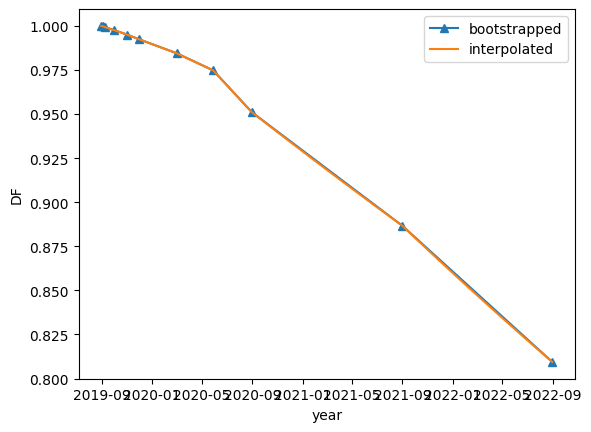

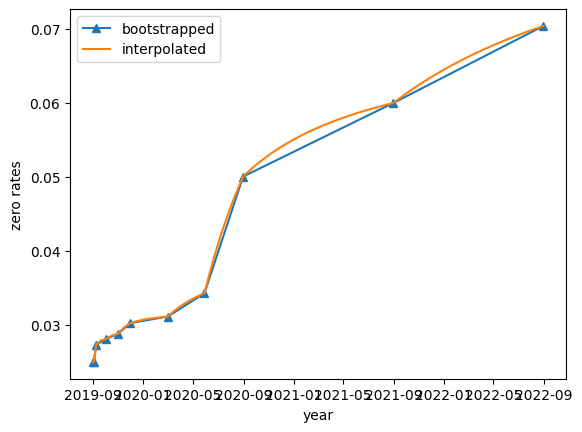

In [11]:
plt.figure(3)
dates_final = boot_curve.get_dates()
df_final = boot_curve.get_df()

# calculated df from dates
dates_new = [dates_final[0]]
days = 10  # create a smoother curve by adding dates in between
for i in range(1, len(dates_final)):
    while dates_new[-1] + dt.timedelta(days=days) < dates_final[i]:
        dates_new.append(dates_new[-1] + dt.timedelta(days=days))
    dates_new.append(dates_final[i])

print(dates_new)
values = [boot_curve.rivapy_value(boot_curve.refdate, d) for d in dates_new]
print(values)

plt.plot(dates_final, df_final, marker="^", label="bootstrapped")
plt.plot(dates_new, values, label="interpolated")

plt.xlabel("year")
plt.ylabel("DF")
plt.legend()

# continuous compounding
plt.figure(4)
dcc = DayCounter(boot_curve.daycounter)
zero_final = []
for i in range(1, len(df_final)):
    delta_t = dcc.yf(boot_curve.refdate, dates_final[i])  # float((dates_new[i] - estr.refdate).days) / 365.0
    zero_final.append(-math.log(df_final[i]) / delta_t)
zero_final.insert(0, zero_final[0])  # adding first entry to account for division by zero for dt

zero_interp = []
for i in range(1, len(values)):
    delta_t = dcc.yf(boot_curve.refdate, dates_new[i])  # float((dates_new[i] - estr.refdate).days) / 365.0
    zero_interp.append(-math.log(values[i]) / delta_t)
zero_interp.insert(0, zero_interp[0])

plt.plot(dates_final, zero_final, marker="^", label="bootstrapped")
# plt.scatter(end_date_deposits, quotes_deposits)
plt.plot(dates_new, zero_interp, label="interpolated")

plt.xlabel("year")
plt.ylabel("zero rates")
plt.legend()
plt.show()

In [12]:
#As a sort of calibration, the bootstrapped curve needs to reproduce the market quotes exactly when repricing the instrumnts using this derived curve

model_quotes = []
pricing_params = {"fixing_grace_period": 0.0, "set_rate": True, "desired_rate": 1.0}
curves_dict = {"discount_curve": boot_curve, "fixing_curve":boot_curve}


for i in range(len(instruments_both)):

    model_quote = get_quote(ref_date, instruments_both[i], curves_dict )
    #print(model_quote)
    model_quotes.append(model_quote)

In [13]:
# we compare the percent difference between the target market quotes and the rates given from the bootstrapped curve
for i in range(len(quotes_both)):

    per_diff = (model_quotes[i] - quotes_both[i])/quotes_both[i] * 100
    print(f"{model_quotes[i]} - {quotes_both[i]}")
    print(f"i:{i} date:{dates_final[i+1]}  percent diff: {per_diff}")

0.024999999999992806 - 0.025
i:0 date:2019-09-03 00:00:00  percent diff: -2.8782531913407183e-11
0.02799999999998407 - 0.028
i:1 date:2019-09-09 00:00:00  percent diff: -5.689893001203927e-11
0.028299999999994774 - 0.0283
i:2 date:2019-10-02 00:00:00  percent diff: -1.8462851977534074e-11
0.028999999857055463 - 0.029
i:3 date:2019-11-01 00:00:00  percent diff: -4.929122005195479e-07
0.03050000023889959 - 0.0305
i:4 date:2019-12-01 00:00:00  percent diff: 7.832773478092107e-07
0.03150000015431079 - 0.0315
i:5 date:2020-03-01 00:00:00  percent diff: 4.898755122891118e-07
0.03480000015798561 - 0.0348
i:6 date:2020-05-29 00:00:00  percent diff: 4.53981639956298e-07
0.05000000000003024 - 0.05
i:7 date:2020-08-31 00:00:00  percent diff: 6.04793992664554e-11
0.059999999999692875 - 0.06
i:8 date:2021-08-31 00:00:00  percent diff: -5.118706384680631e-10
0.06999999999996598 - 0.07
i:9 date:2022-08-31 00:00:00  percent diff: -4.861190814965864e-11


## TODO import instrument data from .csv and file parsing

### EUR market data

We now present the calibration of EUR curves based on actual market data. The input quotes as well as the instrument definition and conventions are provided in an input csv. file and are loaded into a pandas data frame object:

In [14]:
# # set holiday calendar #TODO check how this is handled currently in RIVAPY!!
# holidays = pyvacon.finance.definition.SimpleHolidayCalendar('GER_HOL')
# holidays.setWeekdayAsHoliday(0) # set sunday as holiday
# holidays.setWeekdayAsHoliday(6) # set saturday as holidays

# set directory and file name for Input Quotes
dirName = "./notebooks/marketdata"#"./"
fileName = "/inputQuotes.csv"#"/inputQuotes.csv"

# get instrument quotes and conventions from input .csv file 
column_names = ['Maturity','Instrument','Currency','Quote','UnderlyingIndex','UnderlyingTenor', 'UnderlyingPaymentFrequency',
                'BasisIndex','BasisTenor','BasisPaymentFrequency','PaymentFrequencyFixed','DayCountFixed',
                'DayCountFloat','DayCountBasis','RollConventionFixed','RollConventionFloat','RollConventionBasis', 'SpotLag']

dfQuotes = pd.read_csv(dirName + fileName, sep= ";", decimal =",", skiprows=[0], header=None, names = column_names)
dfQuotes

,Maturity,Instrument,Currency,Quote,UnderlyingIndex,UnderlyingTenor,UnderlyingPaymentFrequency,BasisIndex,BasisTenor,BasisPaymentFrequency,PaymentFrequencyFixed,DayCountFixed,DayCountFloat,DayCountBasis,RollConventionFixed,RollConventionFloat,RollConventionBasis,SpotLag
0,1D,DEPOSIT,EUR,-0.003450,ESTR,1D,1D,NaN,NaN,NaN,1D,Act360,Act360,NaN,ModifiedFollowing,ModifiedFollowing,NaN,0D
1,7D,OIS,EUR,-0.003590,ESTR,7D,7D,NaN,NaN,NaN,7D,Act360,Act360,NaN,ModifiedFollowing,ModifiedFollowing,NaN,2D
2,14D,OIS,EUR,-0.003590,ESTR,14D,14D,NaN,NaN,NaN,14D,Act360,Act360,NaN,ModifiedFollowing,ModifiedFollowing,NaN,2D
3,21D,OIS,EUR,-0.003585,ESTR,21D,21D,NaN,NaN,NaN,21D,Act360,Act360,NaN,ModifiedFollowing,ModifiedFollowing,NaN,2D
4,1M,OIS,EUR,-0.003580,ESTR,1M,1M,NaN,NaN,NaN,1M,Act360,Act360,NaN,ModifiedFollowing,ModifiedFollowing,NaN,2D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,15Y,TBS,EUR,0.000845,EURIBOR,6M,6M,EURIBOR,3M,3M,1Y,Act360,Act360,Act360,ModifiedFollowing,ModifiedFollowing,ModifiedFollowing,2D
71,20Y,TBS,EUR,0.000690,EURIBOR,6M,6M,EURIBOR,3M,3M,1Y,Act360,Act360,Act360,ModifiedFollowing,ModifiedFollowing,ModifiedFollowing,2D
72,30Y,TBS,EUR,0.000515,EURIBOR,6M,6M,EURIBOR,3M,3M,1Y,Act360,Act360,Act360,ModifiedFollowing,ModifiedFollowing,ModifiedFollowing,2D
73,40Y,TBS,EUR,0.000410,EURIBOR,6M,6M,EURIBOR,3M,3M,1Y,Act360,Act360,Act360,ModifiedFollowing,ModifiedFollowing,ModifiedFollowing,2D


In [23]:
#testing 3M Euribor data
dfQuotes3M = dfQuotes[(dfQuotes['UnderlyingIndex'] == 'EURIBOR') & (dfQuotes['UnderlyingTenor'] == '3M')]
print(dfQuotes3M)

   Maturity Instrument Currency     Quote UnderlyingIndex UnderlyingTenor  \
34       3M    DEPOSIT      EUR -0.003290         EURIBOR              3M   
35       6M    DEPOSIT      EUR -0.003277         EURIBOR              3M   
36       9M    DEPOSIT      EUR -0.003238         EURIBOR              3M   
37       1Y        IRS      EUR -0.003204         EURIBOR              3M   
38      15M        IRS      EUR -0.003098         EURIBOR              3M   
39      18M        IRS      EUR -0.002950         EURIBOR              3M   
40      21M        IRS      EUR -0.002786         EURIBOR              3M   
41       2Y        IRS      EUR -0.002615         EURIBOR              3M   
42       3Y        IRS      EUR -0.001730         EURIBOR              3M   
43       4Y        IRS      EUR -0.000647         EURIBOR              3M   
44       5Y        IRS      EUR  0.000570         EURIBOR              3M   
45       6Y        IRS      EUR  0.001850         EURIBOR              3M   

## TODO: multicurve bootstrapping

We want to do multicurve bootstrapping.  
This means we use one curve for discounting cashflows to calculate the present value.  
We use another a seperate curve to determine the forward rates.  
These curves are determined based on market data such that the discount factors and forward rates reproduce the market rates.  

To do this, we create a discount curve first from OIS for applicable maturities.  
Next, we need to then build a forward curve calibrated for each TENOR, i.e. a forward curve for 3M repricing frequency, and thus a different forward curve for 6M repricing freq.  

### Testing bootstrapping with just OIS swaps to make a discount curve

In [15]:


def temp_ois_scheduler(start_dates: list, end_dates: list):

    # CONSIDER USING A SCHEDULER FUNCTION ONCE IT IS FINISHED
    daily_rate_start_dates = []   # 2D list: coupon i -> list of daily starts
    daily_rate_end_dates   = []   # 2D list: coupon i -> list of daily ends
    daily_rate_reset_dates = []   # 2D list: coupon i -> list of reset dates
    pay_dates              = []   # 1D list: one pay date per coupon

    for i in range(len(start_dates)):


        #for this test we keep it simple and ignore conventions e.g. business day or so. i.e just take every day
        num_days = (end_dates[i] - start_dates[i]).days
        daily_schedule = [start_dates[i] + dt.timedelta(days=j) for j in range(num_days)]

        # Build start/end date pairs for accrual periods
        starts = daily_schedule[:-1]   # all except last
        ends   = daily_schedule[1:]    # all except first

        daily_rate_start_dates.append(starts)
        daily_rate_end_dates.append(ends)

        #4. Compute reset dates (fixing lag applied to each start)
        # resets = [add_business_days(start, fixingLag, rateHolidays)
        #           for start in starts]
        #assume simple case reset date is the same as start date
        resets = starts # reset dates are equal to start dates if spot lag is 0.
        daily_rate_reset_dates.append(resets)

        # Compute payment date for the coupon
        #pay_date = add_business_days(end_dates[i], payLag, holidays)
        #assume simple case, pay date is end date
        pay_date=end_dates[i]
        pay_dates.append(pay_date)


    return [daily_rate_start_dates, daily_rate_end_dates, daily_rate_reset_dates, pay_dates]

In [16]:
#Specify a couple of OIS swaps
#Note that here we represent them as a typical IR swap, except that the float leg uses an OIS specification instead of FLoatIRS specification.
# THe fixed IRS specification is used the same


#We will use OIS based on a 1 WEEk, 1M,3M, 6M, 9M underlying indexes
#will assume 1 year maturity for all ...


#MATURITY has to match underlying TENOR????, by that logic, it is just 1 accrual period?
# well it needs to have increasing maturity ... so we will do that for now ...


# calculation date
ref_date = dt.datetime(2019, 8, 31)

#3M maturity 3M underlying tenor swap, i.e. the floating leg is reset every 3M
#since it is OIS

# start dates of the accrual periods corresponding to the tenor of the underlying index (3 months). The spot lag is set to 0.
start_dates = [ref_date + relativedelta(months=3*i) for i in range(1)]


# the end dates of the accrual periods
end_dates = [x + relativedelta(months=3) for x in start_dates]

# the actual payment dates of the cashflows may differ from the end of the accrual period (e.g. OIS). 
# in the standard case these two sets of dates coincide
#pay_dates = end_dates

print(end_dates)
ns = ConstNotionalStructure(100.0)
spread = 0.00

#the difference here is that rate_date arrays are excpected to be 2 dimensional, i.e. keep track of the daily resetting per accrual period

res= temp_ois_scheduler(start_dates, end_dates)

daily_rate_start_dates = res[0]   # 2D list: coupon i -> list of daily starts
daily_rate_end_dates   = res[1]   # 2D list: coupon i -> list of daily ends
daily_rate_reset_dates = res[2]   # 2D list: coupon i -> list of reset dates
pay_dates = res[3]

float_leg = IrOISLegSpecification(obj_id = 'dummy_float_leg', notional = ns, rate_reset_dates=daily_rate_reset_dates, start_dates=start_dates, end_dates=end_dates,
                                   rate_start_dates=daily_rate_start_dates, rate_end_dates=daily_rate_end_dates, pay_dates=pay_dates, currency = "EUR", 
                                   udl_id="test_udl_id", fixing_id="test_fixing_id", day_count_convention="Act365Fixed", rate_day_count_convention="Act365Fixed",spread=spread)

# # definition of the fixed leg
#Note that a fixed rate is given for the specification as it is required. 
#However, for the creation of the bootrstrapped curve, the market quotes are used as the target swap par rate
fixed_leg = IrFixedLegSpecification(fixed_rate = 0.01, obj_id = 'dummy_fixed_leg', notional = 100.0, start_dates=start_dates, 
                                    end_dates=end_dates, pay_dates=pay_dates, currency='EUR', day_count_convention='Act365Fixed')

# # definition of the IR swap
ois_swap_3M = InterestRateSwapSpecification(obj_id="3M_SWAP", notional=ns, issue_date=ref_date, maturity_date=pay_dates[-1],
                                        pay_leg=fixed_leg, receive_leg=float_leg,currency='EUR', day_count_convention="Act365Fixed",
                                        issuer="dummy_issuer", securitization_level="COLLATERALIZED")

[datetime.datetime(2019, 11, 30, 0, 0)]


In [17]:
#6M Maturity, 6M tenor

start_dates = [ref_date + relativedelta(months=6*i) for i in range(1)]


# the end dates of the accrual periods
end_dates = [x + relativedelta(months=6) for x in start_dates]

# the actual payment dates of the cashflows may differ from the end of the accrual period (e.g. OIS). 
# in the standard case these two sets of dates coincide
#pay_dates = end_dates

print(end_dates)
ns = ConstNotionalStructure(100.0)
spread = 0.00

#the difference here is that rate_date arrays are excpected to be 2 dimensional, i.e. keep track of the daily resetting per accrual period

res= temp_ois_scheduler(start_dates, end_dates)

daily_rate_start_dates = res[0]   # 2D list: coupon i -> list of daily starts
daily_rate_end_dates   = res[1]   # 2D list: coupon i -> list of daily ends
daily_rate_reset_dates = res[2]   # 2D list: coupon i -> list of reset dates
pay_dates = res[3]

float_leg = IrOISLegSpecification(obj_id = 'dummy_float_leg', notional = ns, rate_reset_dates=daily_rate_reset_dates, start_dates=start_dates, end_dates=end_dates,
                                   rate_start_dates=daily_rate_start_dates, rate_end_dates=daily_rate_end_dates, pay_dates=pay_dates, currency = "EUR", 
                                   udl_id="test_udl_id", fixing_id="test_fixing_id", day_count_convention="Act365Fixed", rate_day_count_convention="Act365Fixed",spread=spread)

# # definition of the fixed leg
#Note that a fixed rate is given for the specification as it is required. 
#However, for the creation of the bootrstrapped curve, the market quotes are used as the target swap par rate
fixed_leg = IrFixedLegSpecification(fixed_rate = 0.01, obj_id = 'dummy_fixed_leg', notional = 100.0, start_dates=start_dates, 
                                    end_dates=end_dates, pay_dates=pay_dates, currency='EUR', day_count_convention='Act365Fixed')

# # definition of the IR swap
ois_swap_6M = InterestRateSwapSpecification(obj_id="6M_SWAP", notional=ns, issue_date=ref_date, maturity_date=pay_dates[-1],
                                        pay_leg=fixed_leg, receive_leg=float_leg,currency='EUR', day_count_convention="Act365Fixed",
                                        issuer="dummy_issuer", securitization_level="COLLATERALIZED")

[datetime.datetime(2020, 2, 29, 0, 0)]


In [18]:
# 9M Maturity, 9M tenor
#we have to make sure teh mat date is correrct

start_dates = [ref_date + relativedelta(months=9*i) for i in range(1)]


# the end dates of the accrual periods
end_dates = [x + relativedelta(months=9) for x in start_dates]


#maturity_date = start_dates[0] + relativedelta(months=12)

# the actual payment dates of the cashflows may differ from the end of the accrual period (e.g. OIS). 
# in the standard case these two sets of dates coincide
#pay_dates = end_dates

print(end_dates)
ns = ConstNotionalStructure(100.0)
spread = 0.00

#the difference here is that rate_date arrays are excpected to be 2 dimensional, i.e. keep track of the daily resetting per accrual period

res= temp_ois_scheduler(start_dates, end_dates)

daily_rate_start_dates = res[0]   # 2D list: coupon i -> list of daily starts
daily_rate_end_dates   = res[1]   # 2D list: coupon i -> list of daily ends
daily_rate_reset_dates = res[2]   # 2D list: coupon i -> list of reset dates
pay_dates = res[3]

float_leg = IrOISLegSpecification(obj_id = 'dummy_float_leg', notional = ns, rate_reset_dates=daily_rate_reset_dates, start_dates=start_dates, end_dates=end_dates,
                                   rate_start_dates=daily_rate_start_dates, rate_end_dates=daily_rate_end_dates, pay_dates=pay_dates, currency = "EUR", 
                                   udl_id="test_udl_id", fixing_id="test_fixing_id", day_count_convention="Act365Fixed", rate_day_count_convention="Act365Fixed",spread=spread)

# # definition of the fixed leg
#Note that a fixed rate is given for the specification as it is required. 
#However, for the creation of the bootrstrapped curve, the market quotes are used as the target swap par rate
fixed_leg = IrFixedLegSpecification(fixed_rate = 0.01, obj_id = 'dummy_fixed_leg', notional = 100.0, start_dates=start_dates, 
                                    end_dates=end_dates, pay_dates=pay_dates, currency='EUR', day_count_convention='Act365Fixed')

# # definition of the IR swap
ois_swap_9M = InterestRateSwapSpecification(obj_id="39_SWAP", notional=ns, issue_date=ref_date, maturity_date=pay_dates[-1],
                                        pay_leg=fixed_leg, receive_leg=float_leg,currency='EUR', day_count_convention="Act365Fixed",
                                        issuer="dummy_issuer", securitization_level="COLLATERALIZED")

[datetime.datetime(2020, 5, 31, 0, 0)]


In [19]:
#1M Maturity, 1 M tenor

start_dates = [ref_date + relativedelta(months=1*i) for i in range(1)]


# the end dates of the accrual periods
end_dates = [x + relativedelta(months=1) for x in start_dates]

# the actual payment dates of the cashflows may differ from the end of the accrual period (e.g. OIS). 
# in the standard case these two sets of dates coincide
#pay_dates = end_dates

print(end_dates)
ns = ConstNotionalStructure(100.0)
spread = 0.00

#the difference here is that rate_date arrays are excpected to be 2 dimensional, i.e. keep track of the daily resetting per accrual period

res= temp_ois_scheduler(start_dates, end_dates)

daily_rate_start_dates = res[0]   # 2D list: coupon i -> list of daily starts
daily_rate_end_dates   = res[1]   # 2D list: coupon i -> list of daily ends
daily_rate_reset_dates = res[2]   # 2D list: coupon i -> list of reset dates
pay_dates = res[3]

float_leg = IrOISLegSpecification(obj_id = 'dummy_float_leg', notional = ns, rate_reset_dates=daily_rate_reset_dates, start_dates=start_dates, end_dates=end_dates,
                                   rate_start_dates=daily_rate_start_dates, rate_end_dates=daily_rate_end_dates, pay_dates=pay_dates, currency = "EUR", 
                                   udl_id="test_udl_id", fixing_id="test_fixing_id", day_count_convention="Act365Fixed", rate_day_count_convention="Act365Fixed",spread=spread)

# # definition of the fixed leg
#Note that a fixed rate is given for the specification as it is required. 
#However, for the creation of the bootrstrapped curve, the market quotes are used as the target swap par rate
fixed_leg = IrFixedLegSpecification(fixed_rate = 0.01, obj_id = 'dummy_fixed_leg', notional = 100.0, start_dates=start_dates, 
                                    end_dates=end_dates, pay_dates=pay_dates, currency='EUR', day_count_convention='Act365Fixed')

# # definition of the IR swap
ois_swap_1M = InterestRateSwapSpecification(obj_id="1M_SWAP", notional=ns, issue_date=ref_date, maturity_date=pay_dates[-1],
                                        pay_leg=fixed_leg, receive_leg=float_leg,currency='EUR', day_count_convention="Act365Fixed",
                                        issuer="dummy_issuer", securitization_level="COLLATERALIZED")

[datetime.datetime(2019, 9, 30, 0, 0)]


In [20]:
#1 deposit needed for the 1 Day tenor
# calculation date
#ref_date = dt.datetime(2019, 8, 31) # refdate = dt.datetime(2017, 8, 31)

# start date of the accrual period with spot lag equal to 2 days
start_date = ref_date + dt.timedelta(days=2)

# end date of the accrual period is 1 day after startdate
end_date = start_date + dt.timedelta(days=1)

# specification of the deposit
ccy = "EUR"
dcc = "Act365Fixed"#"Act360"normally a bond is ACT360, we keep consistency with the swaps
rate = -0.00345
notional = 100.0
deposit_estr = DepositSpecification(
    obj_id="OVERNIGHT_DEPOSIT",
    issuer="dummy_issuer",
    currency=ccy,
    fixing_date=ref_date,
    start_date=start_date,
    maturity_date=end_date,
    notional=notional,
    rate=rate,
    day_count_convention=dcc,
)

Set fixing_date, 2019-08-31 00:00:00, to next business day acc. to business_day_convention:2019-08-30 00:00:00
Set term to the difference between end_date and start_date in days.


## bootstrap DC using only OIS swap and 1 Deposit

In [21]:
#combine the multiple instruments to be given to the bootstrapper
instruments_ois = [ois_swap_1M,ois_swap_3M,ois_swap_6M,ois_swap_9M]
quotes_ois = [-0.00358, -0.00358, -0.00358, -0.00357] #taken from the .csv as example

# instruments_ois = [ois_swap_3M, ois_swap_6M]
# quotes_ois = [-0.00358, -0.00358] #taken from the .csv as example

instruments_ois = [deposit_estr, ois_swap_1M,ois_swap_3M,ois_swap_6M,ois_swap_9M]
quotes_ois = [-0.00345, -0.00358, -0.00358, -0.00358, -0.00357] #taken from the .csv as example

instruments_ois = [deposit_estr, ois_swap_1M]
quotes_ois = [-0.00345, -0.00358] #taken from the .csv as example

# instruments_ois = [deposit_estr, ir_swap]
# quotes_ois = [-0.00345, 0.05] #taken from the .csv as example

boot_curve_ois = bootstrap_curve(ref_date, 'bootstrapped_ois_DC', DayCounterType.Act365Fixed,  
                       instruments_ois, quotes_ois, 
                       interpolation_type =InterpolationType.LINEAR_LOG, 
                       extrapolation_type= ExtrapolationType.LINEAR_LOG)

Exception: Initial bootstrap failed at 2019-09-30 00:00:00: f(a) and f(b) must have different signs

In [ ]:
#PLotting Discount Curve

plt.figure(5)
dates_final = boot_curve_ois.get_dates()
df_final = boot_curve_ois.get_df()

# calculated df from dates
dates_new = [dates_final[0]]
days = 10  # create a smoother curve by adding dates in between
for i in range(1, len(dates_final)):
    while dates_new[-1] + dt.timedelta(days=days) < dates_final[i]:
        dates_new.append(dates_new[-1] + dt.timedelta(days=days))
    dates_new.append(dates_final[i])

print(dates_new)
values = [boot_curve_ois.rivapy_value(boot_curve_ois.refdate, d) for d in dates_new]
print(values)

plt.plot(dates_final, df_final, marker="^", label="bootstrapped")
plt.plot(dates_new, values, label="interpolated")

plt.xlabel("year")
plt.ylabel("DF")
plt.legend()

# continuous compounding
plt.figure(6)
dcc = DayCounter(boot_curve_ois.daycounter)
zero_final = []
for i in range(1, len(df_final)):
    delta_t = dcc.yf(boot_curve_ois.refdate, dates_final[i])  # float((dates_new[i] - estr.refdate).days) / 365.0
    zero_final.append(-math.log(df_final[i]) / delta_t)
zero_final.insert(0, zero_final[0])  # adding first entry to account for division by zero for dt

zero_interp = []
for i in range(1, len(values)):
    delta_t = dcc.yf(boot_curve_ois.refdate, dates_new[i])  # float((dates_new[i] - estr.refdate).days) / 365.0
    zero_interp.append(-math.log(values[i]) / delta_t)
zero_interp.insert(0, zero_interp[0])

plt.plot(dates_final, zero_final, marker="^", label="bootstrapped")
# plt.scatter(end_date_deposits, quotes_deposits)
plt.plot(dates_new, zero_interp, label="interpolated")

plt.xlabel("year")
plt.ylabel("zero rates")
plt.legend()
plt.show()

### Getting discount factors

In [ ]:
# OIS discount factors
# get input data for the ESTR curve used for overnight index swaps
dfQuotesOIS = dfQuotes[dfQuotes['UnderlyingIndex'] == 'ESTR']



print(dfQuotesOIS)

In [ ]:
# set up curve parameters for bootstrapping algorithm
estrCurveSpec =  {'refDate': ref_date, 
                  'curveName': 'eonia', # shoudlnt it be called estr???
                  'dayCount': 'Act365Fixed',
                  'calendar': holidays} #TODO how to pass the holidays with a calendar object
# get estr curve             
#estrCurve = bootstr.bootstrap_curve_from_quote_table(dfQuotesOIS, estrCurveSpec)
#TODO create function to bootstrap from given market data table, wrapper?

In [ ]:
#testing cells
dfQuotesOIS = dfQuotes[dfQuotes['UnderlyingIndex'] == 'ESTR']
dfQuotesOIS

In [ ]:
#setting up an OIS swap




### Getting forward curve for a specific tenor e.g., 3M

In [ ]:
# get input data for the 3M EURIBOR curve
dfQuotes3M = dfQuotes[(dfQuotes['UnderlyingIndex'] == 'EURIBOR') & (dfQuotes['UnderlyingTenor'] == '3M')]

# set up curve parameters for the 3M EURIBOR curve. The eonia curve is used for bootstrapping
euribor3MCurveSpec =  {'refDate': refdate, 
                       'curveName': 'euribor_3M',
                       'dayCount': 'Act365Fixed',
                       'calendar': holidays,#TODO how to pass the holidays with a calendar object
                       'discountCurve': estrCurve} #discoutn curve needs to be produce first

In [ ]:
#testing cells
# get input data for the 3M EURIBOR curve
dfQuotes3M = dfQuotes[(dfQuotes['UnderlyingIndex'] == 'EURIBOR') & (dfQuotes['UnderlyingTenor'] == '3M')]

In [ ]:
dfQuotes3M

### Generating the 6M forward curve given a basis curve?


TODO: explain

In [ ]:
# get input data for the 6M EURIBOR curve
dfQuotes6M = dfQuotes[(dfQuotes['UnderlyingIndex'] == 'EURIBOR') & (dfQuotes['UnderlyingTenor'] == '6M')]

# set up curve parameters for the 6M EURIBOR curve
euribor6MCurveSpec =  {'refDate': ref_date,
                      'curveName': 'euribor_6M',
                      'dayCount': 'Act365Fixed',
                      'calendar': holidays,#TODO how to pass the holidays with a calendar object
                      'discountCurve': estrCurve, #discoutn curve needs to be produce first
                      'basisCurve': euribor3MCurve}#basis curve needs to be determined - what is the relation between 6M and 3M
# get 6M euribor curve             
#euribor6MCurve = bootstr.bootstrap_curve_from_quote_table(dfQuotes6M, euribor6MCurveSpec) #TODO function

## TODO: other instruments